# Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization,
    RandomFlip,
    RandomRotation,
    RandomZoom
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

## Load Dataset


In [5]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


# Class Names

In [6]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# Normalize Images

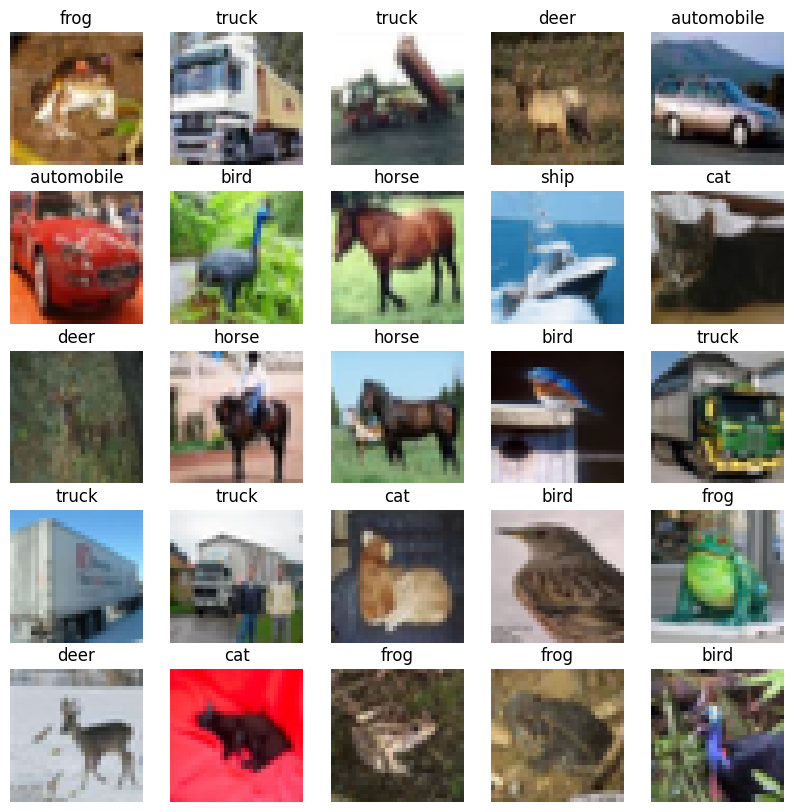

In [7]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

# Data For ANN

In [8]:
x_train_flat = x_train.reshape(50000, 3072)
x_test_flat = x_test.reshape(10000, 3072)

print(x_train_flat.shape)

(50000, 3072)


## ANN

In [9]:
ann_model = Sequential([

    Dense(512, activation='relu', input_shape=(3072,)),
    Dropout(0.3),

    Dense(256, activation='relu'),

    Dense(10, activation='softmax')

])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## Train ANN

In [10]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.1015 - loss: 13.4675 - val_accuracy: 0.0958 - val_loss: 2.3094
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.0972 - loss: 2.3028 - val_accuracy: 0.0970 - val_loss: 2.3064
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.0992 - loss: 2.3028 - val_accuracy: 0.0974 - val_loss: 2.3058
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.0982 - loss: 2.3025 - val_accuracy: 0.0976 - val_loss: 2.3057
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.0988 - loss: 2.3027 - val_accuracy: 0.0950 - val_loss: 2.3061
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.0981 - loss: 2.3028 - val_accuracy: 0.0950 - val_loss: 2.3060
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.0989 - loss: 2.3026 - val_accuracy: 0.0952 - val_loss: 2.3074
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.0979 - loss: 2.3028 -

## Evaluate ANN

In [11]:
ann_loss, ann_acc = ann_model.evaluate(
    x_test_flat,
    y_test
)

print("ANN Accuracy:", ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1001 - loss: 2.3025
ANN Accuracy: 0.10010000318288803


# CNN

In [12]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )

])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# Train CNN

In [13]:
cnn_history = cnn_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 90ms/step - accuracy: 0.2909 - loss: 2.1070 - val_accuracy: 0.4398 - val_loss: 1.5247
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.4498 - loss: 1.5293 - val_accuracy: 0.5084 - val_loss: 1.3492
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 88ms/step - accuracy: 0.5203 - loss: 1.3583 - val_accuracy: 0.5738 - val_loss: 1.2150
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.5656 - loss: 1.2271 - val_accuracy: 0.6126 - val_loss: 1.1171
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.5998 - loss: 1.1432 - val_accuracy: 0.6258 - val_loss: 1.0796
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.6197 - loss: 1.0873 - val_accuracy: 0.6400 - val_loss: 1.0443
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.6387 - loss: 1.0309 - val_accuracy: 0.6400 - val_loss: 1.0442
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.6600 - loss: 0.9716 - 

# Evaluate CNN

In [14]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test,
    y_test
)

print("CNN Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6787 - loss: 1.1424
CNN Accuracy: 0.6786999702453613


# CNN + BatchNorm

In [15]:
cnn_bn = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )

])

cnn_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train CNN + BatchNorm

In [16]:
bn_history = cnn_bn.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 129ms/step - accuracy: 0.4516 - loss: 1.6334 - val_accuracy: 0.5704 - val_loss: 1.2104
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.5964 - loss: 1.1516 - val_accuracy: 0.5630 - val_loss: 1.2540
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.6559 - loss: 0.9887 - val_accuracy: 0.6378 - val_loss: 1.0129
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 129ms/step - accuracy: 0.6930 - loss: 0.8742 - val_accuracy: 0.5034 - val_loss: 1.7780
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7245 - loss: 0.7833 - val_accuracy: 0.6736 - val_loss: 0.9551
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7500 - loss: 0.7164 - val_accuracy: 0.5224 - val_loss: 1.5050
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.7692 - loss: 0.6566 - val_accuracy: 0.6696 - val_loss: 1.0322
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 129ms/step - accuracy: 0.7880 - loss:

# Evaluate CNN + BatchNorm

In [17]:
bn_loss, bn_acc = cnn_bn.evaluate(
    x_test,
    y_test
)

print("CNN + BatchNorm Accuracy:", bn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7387 - loss: 0.9490
CNN + BatchNorm Accuracy: 0.7386999726295471


# Data Augmentation

In [18]:
data_augmentation = Sequential([

    RandomFlip("horizontal"),

    RandomRotation(0.1),

    RandomZoom(0.1)

])

# CNN + Augmentation

In [19]:
aug_model = Sequential([

    data_augmentation,

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )

])

aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Augmented CNN

In [20]:
aug_history = aug_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 106s 143ms/step - accuracy: 0.3816 - loss: 1.7145 - val_accuracy: 0.4620 - val_loss: 1.5095
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.4876 - loss: 1.4541 - val_accuracy: 0.5724 - val_loss: 1.2047
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 142ms/step - accuracy: 0.5299 - loss: 1.3403 - val_accuracy: 0.5116 - val_loss: 1.5640
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 140ms/step - accuracy: 0.5610 - loss: 1.2561 - val_accuracy: 0.6102 - val_loss: 1.0884
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 142ms/step - accuracy: 0.5847 - loss: 1.1951 - val_accuracy: 0.6208 - val_loss: 1.0882
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 140ms/step - accuracy: 0.6044 - loss: 1.1477 - val_accuracy: 0.5678 - val_loss: 1.2739
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 139ms/step - accuracy: 0.6210 - loss: 1.0981 - val_accuracy: 0.6232 - val_loss: 1.0476
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 141ms/step - accuracy: 0.6290 - l

# Evaluate Augmented CNN

In [21]:
aug_loss, aug_acc = aug_model.evaluate(
    x_test,
    y_test
)

print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6771 - loss: 0.9398
Augmented CNN Accuracy: 0.6771000027656555


# Accuracy Comparision

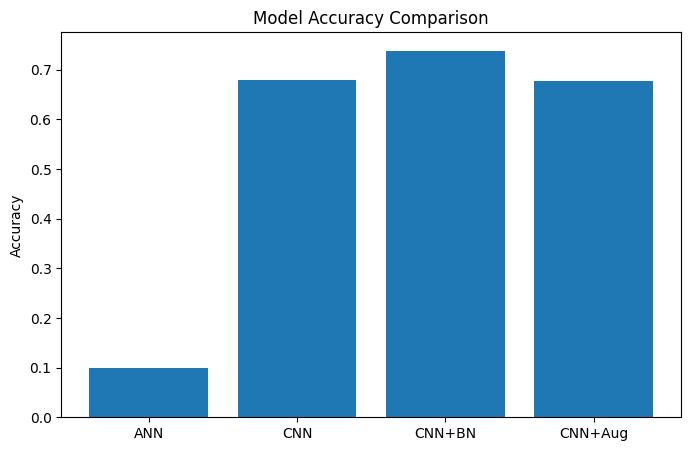

In [22]:
models = [
    "ANN",
    "CNN",
    "CNN+BN",
    "CNN+Aug"
]

accuracies = [
    ann_acc,
    cnn_acc,
    bn_acc,
    aug_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

# Training Curves

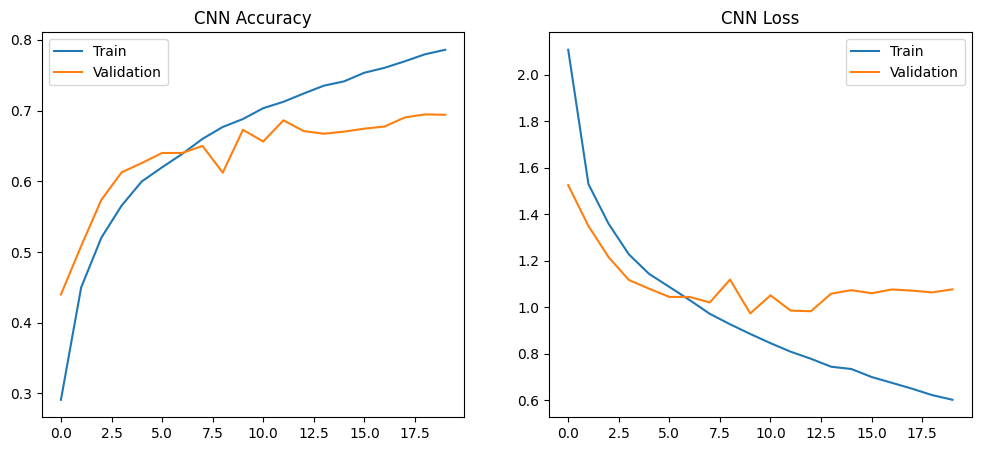

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    cnn_history.history['accuracy'],
    label='Train'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='Validation'
)

plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(
    cnn_history.history['loss'],
    label='Train'
)

plt.plot(
    cnn_history.history['val_loss'],
    label='Validation'
)

plt.title("CNN Loss")
plt.legend()

plt.show()

# Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


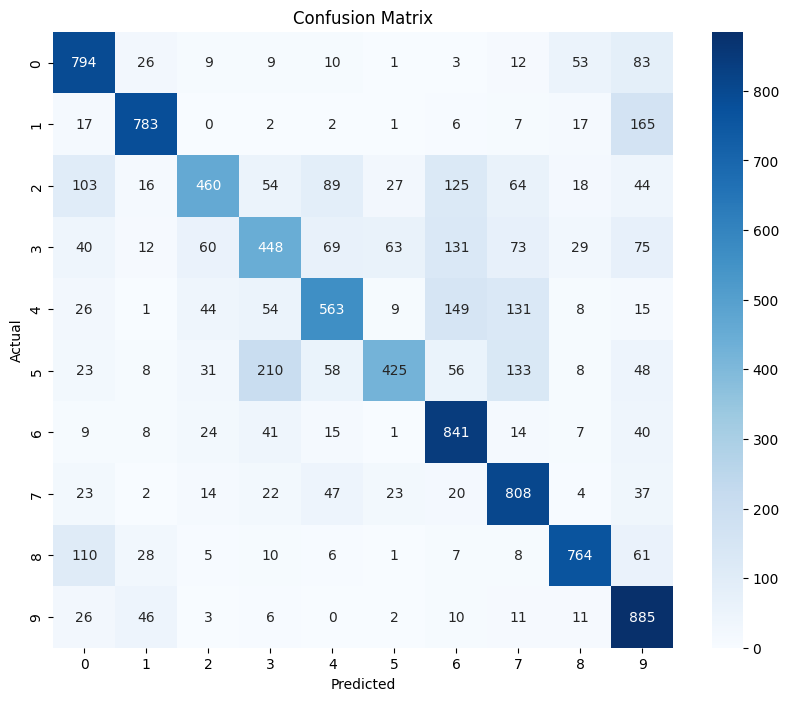

In [24]:
predictions = aug_model.predict(x_test)

predictions = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report

In [25]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.68      0.79      0.73      1000
  automobile       0.84      0.78      0.81      1000
        bird       0.71      0.46      0.56      1000
         cat       0.52      0.45      0.48      1000
        deer       0.66      0.56      0.61      1000
         dog       0.77      0.42      0.55      1000
        frog       0.62      0.84      0.72      1000
       horse       0.64      0.81      0.71      1000
        ship       0.83      0.76      0.80      1000
       truck       0.61      0.89      0.72      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.67     10000
weighted avg       0.69      0.68      0.67     10000



# Find Best Model

In [26]:
# Store model accuracies

model_results = {
    "ANN": ann_acc,
    "CNN": cnn_acc,
    "CNN + BatchNorm": bn_acc,
    "CNN + Data Augmentation": aug_acc
}

# Print all accuracies
print("\nModel Accuracies:")
for model, acc in model_results.items():
    print(f"{model}: {acc:.4f}")

# Find best model
best_model_name = max(model_results, key=model_results.get)
best_accuracy = model_results[best_model_name]

print("\n" + "="*50)
print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print("="*50)


Model Accuracies:
ANN: 0.1001
CNN: 0.6787
CNN + BatchNorm: 0.7387
CNN + Data Augmentation: 0.6771

Best Model: CNN + BatchNorm
Best Accuracy: 0.7387


In [27]:
if best_model_name == "ANN":
    best_model = ann_model

elif best_model_name == "CNN":
    best_model = cnn_model

elif best_model_name == "CNN + BatchNorm":
    best_model = cnn_bn

else:
    best_model = aug_model

best_model.save("best_cifar10_model.h5")

print(f"Saved Best Model: {best_model_name}")

Saved Best Model: CNN + BatchNorm
